<a href="https://colab.research.google.com/github/itzsaruyan-lgtm/FoodwastePrediction/blob/main/Food-Waste-Prediction/Food_Waste_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)

######EDA is used to understand the dataset before building the machine learning model.

In this step, we will check:

1. **Dataset Review** :
   Check `head()`, `tail()`, `shape`

2. **Data Quality Check** :
   Check missing values, duplicates, and data types

3. **Statistical Review** :
   Find mean, median, min, max, and standard deviation

4. **Feature Review** :
   Identify numerical and categorical columns

5. **Distribution Analysis** :
   Analyze the distribution of features

6. **Relationship Analysis** :
   Check relationships and correlation

7. **Outlier Analysis** :
   Identify and analyze outliers


###Dataset Overview

In [ ]:
df = pd.read_csv("/content/food_wastage_data.csv")
print(df.shape)
print(f"So This DataSet have {df.shape[0]} rows and {df.shape[1]} columms.")

(1782, 11)
So This DataSet have 1782 rows and 11 columms.


In [ ]:
df.head(10)

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25
5,Meat,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
6,Meat,240,Wedding,450,Refrigerated,Regular,Winter,Sit-down Dinner,Urban,Low,20
7,Meat,300,Wedding,400,Refrigerated,Regular,Summer,Finger Food,Rural,Moderate,25
8,Fruits,320,Corporate,400,Refrigerated,Regular,All Seasons,Buffet,Urban,High,45
9,Meat,400,Corporate,500,Refrigerated,Occasional,Winter,Finger Food,Urban,High,40


In [ ]:
df.tail(10)

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
1772,Fruits,429,Wedding,496,Room Temperature,Regular,Summer,Sit-down Dinner,Suburban,Low,42
1773,Vegetables,350,Corporate,450,Refrigerated,Regular,Summer,Sit-down Dinner,Urban,High,35
1774,Fruits,491,Birthday,497,Room Temperature,Regular,All Seasons,Finger Food,Urban,High,32
1775,Meat,350,Birthday,450,Room Temperature,Regular,Winter,Sit-down Dinner,Urban,Moderate,25
1776,Meat,491,Social Gathering,497,Room Temperature,Regular,Winter,Finger Food,Urban,High,32
1777,Baked Goods,310,Corporate,350,Room Temperature,Regular,Summer,Finger Food,Urban,High,35
1778,Baked Goods,284,Social Gathering,443,Room Temperature,Regular,Winter,Buffet,Rural,Low,32
1779,Fruits,220,Wedding,300,Room Temperature,Regular,All Seasons,Finger Food,Urban,Moderate,15
1780,Fruits,250,Wedding,350,Room Temperature,Regular,All Seasons,Finger Food,Rural,Moderate,20
1781,Baked Goods,400,Wedding,500,Room Temperature,Regular,Winter,Sit-down Dinner,Rural,High,45


###Data Quality Check

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB


In [ ]:
df.duplicated().sum()

np.int64(164)

In [ ]:
df[df.duplicated()]

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
163,Fruits,220,Birthday,300,Room Temperature,Regular,All Seasons,Finger Food,Suburban,Moderate,15
198,Baked Goods,220,Wedding,300,Room Temperature,Regular,Winter,Finger Food,Rural,Moderate,15
207,Vegetables,220,Corporate,300,Refrigerated,Occasional,Summer,Finger Food,Suburban,Moderate,15
242,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
246,Meat,350,Birthday,450,Refrigerated,Regular,Winter,Finger Food,Suburban,High,30
...,...,...,...,...,...,...,...,...,...,...,...
1761,Baked Goods,320,Birthday,400,Room Temperature,Regular,Winter,Buffet,Rural,High,30
1762,Fruits,310,Corporate,350,Room Temperature,Regular,Summer,Finger Food,Urban,High,35
1764,Meat,320,Social Gathering,400,Refrigerated,Regular,All Seasons,Buffet,Rural,High,30
1771,Meat,350,Wedding,450,Refrigerated,Regular,All Seasons,Sit-down Dinner,Suburban,High,35


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

###Statistical Review

In [ ]:
df.describe()

,Number of Guests,Quantity of Food,Wastage Food Amount
count,1618.000000,1618.000000,1618.000000
mean,318.380717,412.224969,28.628554
std,67.946519,64.714186,10.398187
min,207.000000,280.000000,10.000000
25%,267.750000,350.000000,20.000000
50%,302.000000,400.000000,27.000000
75%,362.750000,480.000000,35.000000
max,491.000000,500.000000,63.000000


###Feature Review

In [ ]:
Numerical_columns = df.select_dtypes(include=np.number).columns
Categorical_columns = df.select_dtypes(exclude=np.number).columns

In [ ]:
print("Numerical Columns:")
print(Numerical_columns)
print("\nCategorical Columns:")
print(Categorical_columns)

Numerical Columns:
Index(['Number of Guests', 'Quantity of Food', 'Wastage Food Amount'], dtype='object')

Categorical Columns:
Index(['Type of Food', 'Event Type', 'Storage Conditions', 'Purchase History',
       'Seasonality', 'Preparation Method', 'Geographical Location',
       'Pricing'],
      dtype='object')


In [ ]:
df['Purchase History'].value_counts()

,count
Purchase History,
Regular,1417
Occasional,201


###Distribution Analysis

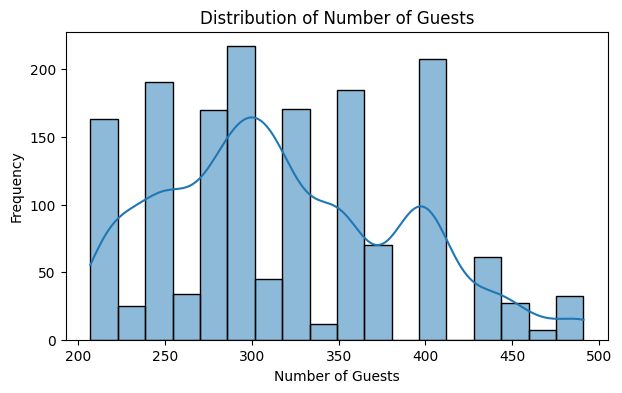

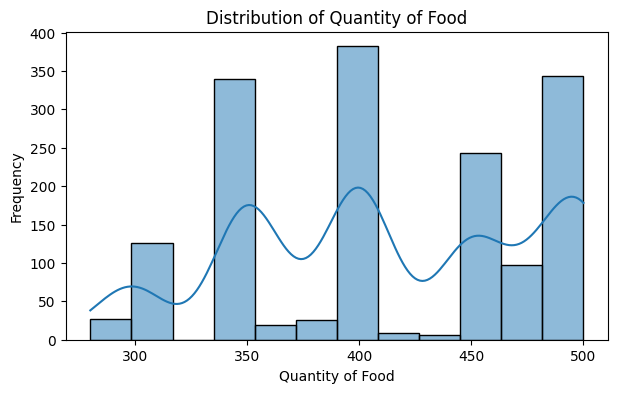

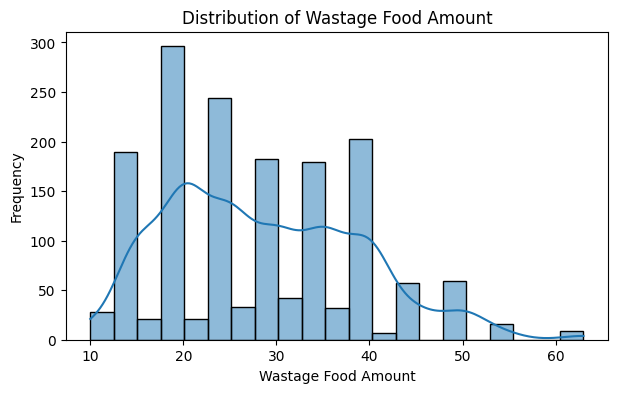

In [ ]:
for col in Numerical_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

###Outlier Analysis

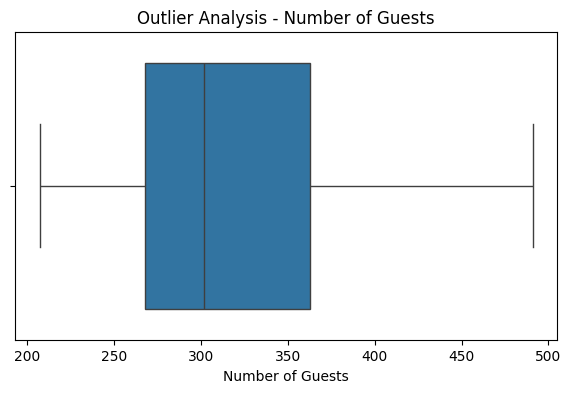

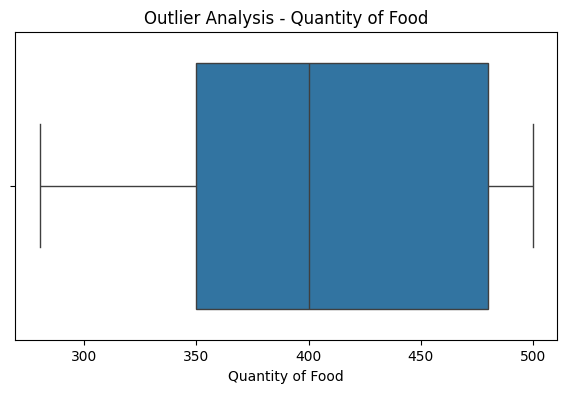

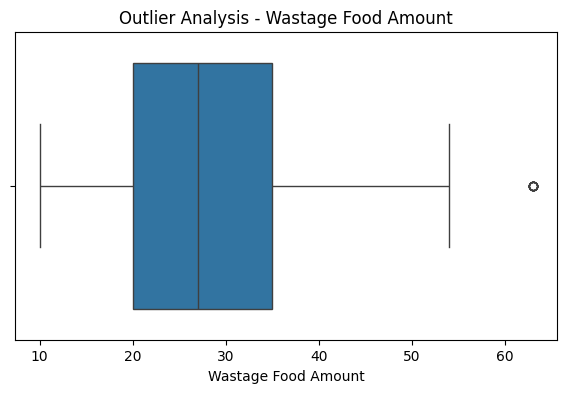

In [ ]:
for col in Numerical_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Analysis - {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
for col in Numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Number of Guests: 0 outliers
Quantity of Food: 0 outliers
Wastage Food Amount: 9 outliers


In [ ]:
outliers = df[
    (df['Wastage Food Amount'] < lower) |
    (df['Wastage Food Amount'] > upper)
]

outliers

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
211,Dairy Products,488,Corporate,498,Room Temperature,Regular,Summer,Finger Food,Suburban,High,63
263,Fruits,488,Corporate,498,Room Temperature,Regular,Summer,Finger Food,Rural,High,63
334,Baked Goods,488,Corporate,498,Room Temperature,Regular,Summer,Finger Food,Suburban,High,63
852,Meat,488,Social Gathering,498,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,63
928,Meat,488,Wedding,498,Refrigerated,Regular,Winter,Finger Food,Rural,High,63
1007,Baked Goods,488,Wedding,498,Room Temperature,Regular,Winter,Finger Food,Rural,High,63
1298,Fruits,488,Social Gathering,498,Room Temperature,Regular,Winter,Finger Food,Rural,High,63
1327,Dairy Products,488,Corporate,498,Room Temperature,Regular,All Seasons,Finger Food,Urban,High,63
1741,Baked Goods,488,Corporate,498,Room Temperature,Regular,Winter,Finger Food,Urban,High,63


###Encoding

In [ ]:
df = pd.get_dummies(df, columns=Categorical_columns, drop_first=True)

In [ ]:
df.head()

,Number of Guests,Quantity of Food,Wastage Food Amount,Type of Food_Dairy Products,Type of Food_Fruits,Type of Food_Meat,Type of Food_Vegetables,Event Type_Corporate,Event Type_Social Gathering,Event Type_Wedding,Storage Conditions_Room Temperature,Purchase History_Regular,Seasonality_Summer,Seasonality_Winter,Preparation Method_Finger Food,Preparation Method_Sit-down Dinner,Geographical Location_Suburban,Geographical Location_Urban,Pricing_Low,Pricing_Moderate
0,310,450,25,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,True,False
1,400,500,40,False,False,True,False,False,False,False,True,True,False,True,False,False,True,False,False,False
2,302,371,27,False,False,False,True,False,False,False,False,True,True,False,False,False,True,False,True,False
3,491,497,32,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False
4,300,400,25,False,False,True,False,True,False,False,False,True,False,True,True,False,False,True,False,True


In [ ]:
df.dtypes

,0
Number of Guests,int64
Quantity of Food,int64
Wastage Food Amount,int64
Type of Food_Dairy Products,bool
Type of Food_Fruits,bool
Type of Food_Meat,bool
Type of Food_Vegetables,bool
Event Type_Corporate,bool
Event Type_Social Gathering,bool
Event Type_Wedding,bool


###Correlation Analysis

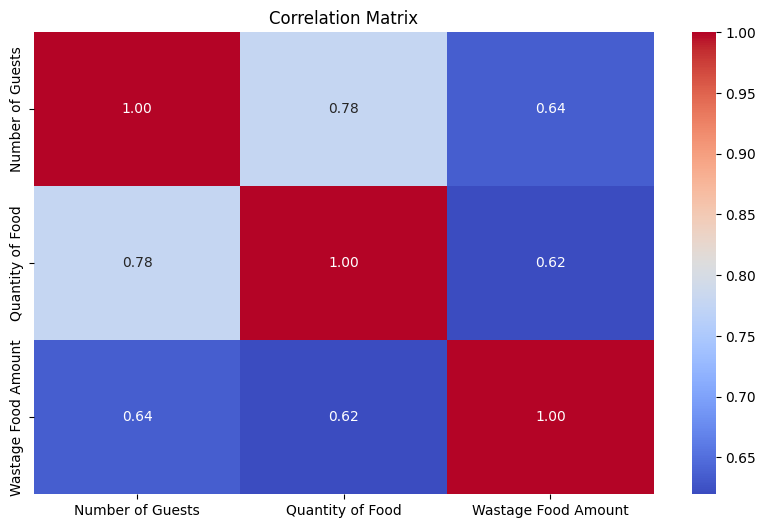

In [ ]:
corr_matrix = df[Numerical_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
target_corr = corr_matrix['Wastage Food Amount'].sort_values(ascending=False)
print(target_corr)

Wastage Food Amount    1.000000
Number of Guests       0.635116
Quantity of Food       0.619651
Name: Wastage Food Amount, dtype: float64


###Train-Test Split

In [ ]:
X = df.drop('Wastage Food Amount', axis=1)
y = df['Wastage Food Amount']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1294, 19)
X_test: (324, 19)
y_train: (1294,)
y_test: (324,)


###Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Model Building Using Pipelines

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train_scaled, y_train)

y_pred_lr = lr_pipeline.predict(X_test_scaled)

In [ ]:
rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train_scaled, y_train)

y_pred_rf = rf_pipeline.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, y_pred in [
    ('Linear Regression', y_pred_lr),
    ('Random Forest', y_pred_rf)
]:

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print()

Linear Regression
MAE : 4.13906931624665
RMSE: 5.393618829270558
R²  : 0.7300125547792697

Random Forest
MAE : 1.9721729864785416
RMSE: 3.1728777166473963
R²  : 0.9065692713227224



In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,4.139069,5.393619,0.730013
1,Random Forest,1.972173,3.172878,0.906569


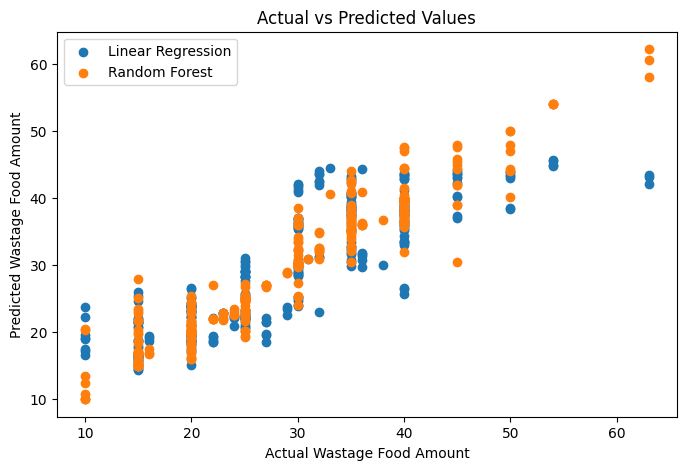

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr, label='Linear Regression')
plt.scatter(y_test, y_pred_rf, label='Random Forest')

plt.xlabel('Actual Wastage Food Amount')
plt.ylabel('Predicted Wastage Food Amount')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

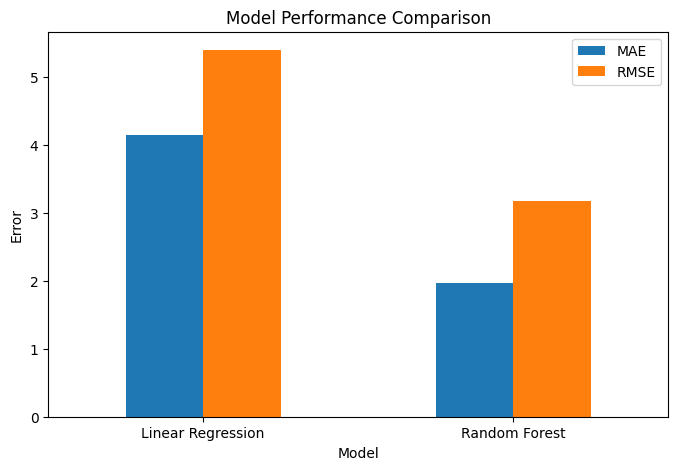

In [ ]:
results.plot(
    x='Model',
    y=['MAE', 'RMSE'],
    kind='bar',
    figsize=(8, 5)
)

plt.title('Model Performance Comparison')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.show()

## Model Comparison and Best Model Selection

The models were evaluated using **MAE, RMSE, and R²**.

- **MAE:** Lower is better
- **RMSE:** Lower is better
- **R²:** Higher is better

Based on the results, **Random Forest Regressor** achieved:
- MAE = **1.97**
- RMSE = **3.17**
- R² = **0.91**

Therefore, **Random Forest Regressor is selected as the best-performing model** for predicting food waste.

###  Conclusion

* The project successfully predicts **food waste amount in restaurants** using Machine Learning.
* Two regression models, **Linear Regression** and **Random Forest Regressor**, were compared.
* **Random Forest Regressor** performed better based on MAE, RMSE, and R².
* Therefore, **Random Forest Regressor was selected as the best model**.

###  Key Takeaways

* Machine Learning can help restaurants **predict food waste**.
* **Random Forest** provided more accurate predictions than Linear Regression.
* Accurate prediction can support **better food planning and resource management**.
* This can help restaurants **reduce unnecessary food waste and improve efficiency**.


In [ ]:
import pandas as pd

# Get user inputs
number_of_guests = float(input("Number of Guests: "))
quantity_of_food = float(input("Quantity of Food: "))

type_of_food = input("Type of Food: ")
event_type = input("Event Type: ")
storage_conditions = input("Storage Conditions: ")
purchase_history = input("Purchase History: ")
seasonality = input("Seasonality: ")
preparation_method = input("Preparation Method: ")
geographical_location = input("Geographical Location: ")
pricing = (input("Pricing: "))


# Create input DataFrame
new_data_raw = pd.DataFrame({
    'Number of Guests': [number_of_guests],
    'Quantity of Food': [quantity_of_food],
    'Type of Food': [type_of_food],
    'Event Type': [event_type],
    'Storage Conditions': [storage_conditions],
    'Purchase History': [purchase_history],
    'Seasonality': [seasonality],
    'Preparation Method': [preparation_method],
    'Geographical Location': [geographical_location],
    'Pricing': [pricing]
})

# Assuming 'Categorical_columns' is available from previous steps
# and 'X' (the training feature DataFrame) is also available
# from previous steps for column alignment.

# One-hot encode the new data
new_data_encoded = pd.get_dummies(new_data_raw, columns=Categorical_columns, drop_first=True)

# Align columns with the training data (X) to ensure all columns are present and in the correct order
new_data = new_data_encoded.reindex(columns=X.columns, fill_value=0)

# Predict wastage
# 'rf_pipeline' is the model selected as the best performing one.
prediction = rf_pipeline.predict(new_data)

print("\n================================")
print("Predicted Food Wastage Amount:", prediction[0])
print("================================")

Number of Guests: 498
Quantity of Food: 550
Type of Food: Meat
Event Type: Wedding
Storage Conditions: Room Temprature
Purchase History: Regular
Seasonality: Winter
Preparation Method: Buffet
Geographical Location: Rural
